# Clase 03 — Del problema a los datos: explorando el llanto infantil con Python

## Pregunta de trabajo

> **¿Qué podemos aprender de un corpus de grabaciones de llanto infantil antes de intentar clasificarlo?**

En esta clase no entrenaremos un modelo. Primero vamos a **escuchar, visualizar y comprender** señales reales.

```text
problema → datos → auditoría → escucha → representaciones → observaciones → preguntas nuevas
```

Las etiquetas del corpus se tratarán como **metadatos del dataset**, no como diagnósticos clínicos ni como firmas acústicas demostradas de una causa.

### ¿Por qué estudiar científicamente el llanto infantil?

El llanto es una de las primeras formas de vocalización humana y constituye una señal acústica compleja. Su estudio ha despertado interés en áreas tan distintas como el desarrollo temprano, la comunicación, la salud, la acústica y, más recientemente, la ciencia de datos y el aprendizaje de máquina.

Un ejemplo particularmente interesante es el trabajo de @mampe2009. Los autores estudiaron la **melodía del llanto de recién nacidos franceses y alemanes** y observaron diferencias en sus contornos melódicos. Sus resultados sugieren que ciertas características prosódicas del entorno lingüístico escuchado durante la gestación pueden influir ya en las primeras vocalizaciones.

Desde otra perspectiva, @lawford2022 realizaron una revisión sistemática y meta-análisis sobre características acústicas del llanto y disfunción neurológica. Este tipo de investigación muestra que propiedades como la frecuencia fundamental y los patrones melódicos pueden ser científicamente informativas, aunque su interpretación requiere cautela y no debe confundirse con un diagnóstico automático.

El desarrollo de herramientas computacionales ha ampliado considerablemente estas posibilidades. Revisiones recientes, como @owino2025 y @sirithepmontree2026, muestran el uso de características y representaciones como **pitch, intensidad, duración, espectrogramas y MFCC**, combinadas con distintos métodos de aprendizaje de máquina.

Existe además una conexión muy directa con nuestra clase. @hammoud2024 utilizaron precisamente el corpus **Donate-a-Cry** que estamos explorando aquí: 457 grabaciones distribuidas en cinco categorías (`hungry`, `discomfort`, `tired`, `belly_pain` y `burping`). Entre las representaciones y características estudiadas se encuentran RMS, ZCR, Mel-spectrogramas y MFCC.

Esto hace que nuestro ejercicio no sea solamente una demostración de Python:

> **estamos trabajando con un pequeño ejemplo de un problema científico real en el que audio, representación matemática y herramientas computacionales se encuentran.**

Pero nuestra estrategia será deliberadamente prudente. Antes de intentar predecir categorías queremos primero **conocer los datos, escucharlos, visualizarlos y comprender qué representaciones estamos construyendo**.

Esa secuencia será importante durante todo el curso:

```text
problema científico
        ↓
datos
        ↓
exploración
        ↓
representación
        ↓
análisis
        ↓
modelo, si realmente tiene sentido
```


## 1. Objetivos

Al finalizar la actividad deberíamos poder:

- leer y escuchar audio desde Jupyter;
- interpretar una forma de onda;
- construir una STFT con frecuencia lineal;
- construir representaciones Mel y log-Mel;
- reconocer periodicidad, armónicos, modulación y estructura temporal;
- distinguir entre **lo que observamos** y **lo que inferimos**.

In [8]:
from pathlib import Path
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
from IPython.display import Audio, display

print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("librosa:", librosa.__version__)

NumPy: 2.5.3
pandas: 3.0.6
librosa: 1.0.0


## 2. Localización del corpus

El notebook busca automáticamente `data_sources` dentro del árbol del proyecto ACUS220.

In [9]:
def find_dataset_root():
    target = Path(
        "data_sources/donateacry-corpus/"
        "donateacry_corpus_cleaned_and_updated_data"
    )
    here = Path.cwd().resolve()
    for parent in [here, *here.parents]:
        candidate = parent / target
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError("No se encontró el corpus Donate-a-Cry.")

DATA_ROOT = find_dataset_root()
print(DATA_ROOT)
print("Existe:", DATA_ROOT.exists())

/Users/vpoblete/Documents/20230208_vpoblete/20260810_acus220/data_sources/donateacry-corpus/donateacry_corpus_cleaned_and_updated_data
Existe: True


## 3. Antes de escuchar: ¿qué dataset tenemos?

Primero contemos las grabaciones por categoría.

In [10]:
wav_paths = sorted(DATA_ROOT.rglob("*.wav"))

corpus = pd.DataFrame({
    "category": [p.parent.name for p in wav_paths],
    "path": [p.relative_to(DATA_ROOT).as_posix() for p in wav_paths],
})

counts = (
    corpus["category"]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="n_wav")
)
counts["percentage"] = (
    100 * counts["n_wav"] / counts["n_wav"].sum()
).round(1)

print(f"Total de WAV: {len(corpus)}")
display(counts)

Total de WAV: 457


,category,n_wav,percentage
0,hungry,382,83.6
1,discomfort,27,5.9
2,tired,24,5.3
3,belly_pain,16,3.5
4,burping,8,1.8


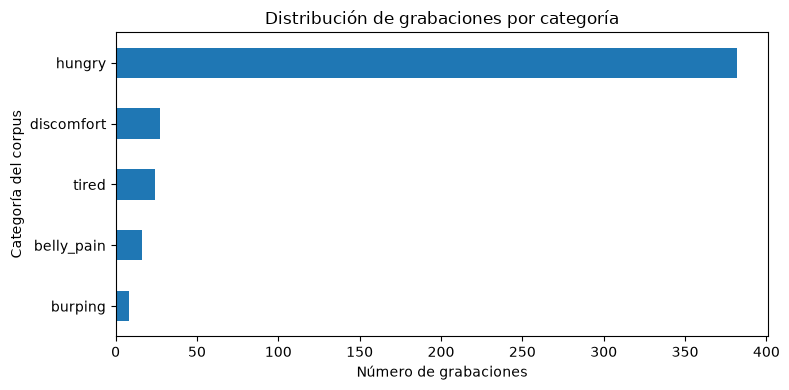

In [11]:
ax = counts.sort_values("n_wav").plot(
    x="category", y="n_wav", kind="barh",
    legend=False, figsize=(8, 4)
)
ax.set_xlabel("Número de grabaciones")
ax.set_ylabel("Categoría del corpus")
ax.set_title("Distribución de grabaciones por categoría")
plt.tight_layout()
plt.show()

### Pregunta para discutir

> **¿Sería una buena idea entrenar inmediatamente un clasificador y evaluar solo con accuracy?**

Antes de elegir un algoritmo conviene comprender cómo están organizados los datos.

### ¿Por qué `accuracy` puede ser engañosa aquí?

La `accuracy` responde a una pregunta muy simple:

$$
\mathrm{accuracy}
=
\frac{\text{número de predicciones correctas}}
     {\text{número total de predicciones}}
$$

El problema es que nuestro corpus está fuertemente desbalanceado.

De las 457 grabaciones:

- 382 pertenecen a `hungry`;
- solo 75 pertenecen, en conjunto, a las otras cuatro categorías.

Imaginemos ahora un clasificador extremadamente simple que **no escucha el audio, no calcula ninguna característica y no aprende nada**:

> **siempre responde `hungry`.**

Ese clasificador acertaría:

$$
\frac{382}{457} \times 100
\approx 83.6\%
$$

Es decir, obtendría aproximadamente **83.6 % de accuracy**.

A primera vista podría parecer un resultado muy bueno.

Sin embargo, ese modelo tendría:

```text
hungry       → muchos aciertos
discomfort   → 0 aciertos
tired        → 0 aciertos
belly_pain   → 0 aciertos
burping      → 0 aciertos
```

> **Una accuracy alta no implica necesariamente que el modelo haya aprendido a distinguir las categorías.**

En un problema desbalanceado necesitamos mirar también cómo se comporta el modelo en cada clase.

Más adelante podremos estudiar herramientas como:

- matriz de confusión;
- precision;
- recall;
- F1-score;
- métricas macro-promediadas.

Pero antes de elegir una métrica o entrenar un modelo aparece una pregunta todavía más importante:

> **¿Qué contienen realmente estas grabaciones y qué diferencias acústicas podemos observar entre ellas?**

Ese será nuestro siguiente paso.

## 4. Cuatro señales con funciones pedagógicas distintas

- **A** — periodicidad, armónicos y modulación suave;
- **C** — modulación pronunciada de F0;
- **D** — episodios temporales y pausas;
- **F** — alto nivel, textura espectral y cambios de régimen.

In [12]:
EXAMPLES = {
    "A": {
        "role": "Periodicidad, armónicos y modulación suave",
        "path": "hungry/F24DE44B-762C-4149-AC92-96A5E57ED118-1430816936-1.0-m-04-hu.wav",
    },
    "C": {
        "role": "Modulación pronunciada de F0",
        "path": "hungry/cda99fcf-d010-47b4-8987-f54be313ddbd-1429973787766-1.7-f-26-hu.wav",
    },
    "D": {
        "role": "Estructura temporal y segmentación",
        "path": "tired/1309B82C-F146-46F0-A723-45345AFA6EA8-1431172241-1.0-f-48-ti.wav",
    },
    "F": {
        "role": "Nivel alto, textura y cambios de régimen",
        "path": "burping/af30880e-5f98-4dc0-b37a-be6b21fa0ba3-1431240072536-1.7-m-26-bu.wav",
    },
}

for key, item in EXAMPLES.items():
    path = DATA_ROOT / item["path"]
    print(f"{key}: {item['role']}")
    print(f"   existe = {path.exists()}")

A: Periodicidad, armónicos y modulación suave
   existe = True
C: Modulación pronunciada de F0
   existe = True
D: Estructura temporal y segmentación
   existe = True
F: Nivel alto, textura y cambios de régimen
   existe = True


## 5. Una señal, varias representaciones

Usaremos siempre la misma secuencia:

```text
forma de onda → escucha → STFT → Mel → log-Mel
```

Dos decisiones diferentes ocurren:

1. **representación de la frecuencia**: lineal o Mel;
2. **representación de la magnitud**: potencia lineal o dB.

### Del audio a una imagen: ¿qué es un espectrograma?

Para esta clase **no necesitamos derivar toda la teoría de Fourier**. Nos interesa comprender el proceso de transformación matemática: qué datos entran, qué transformación aplicamos y qué representación obtenemos.

Una grabación digital puede comenzar como un arreglo unidimensional:

```text
audio
  ↓
y[n]

[0.02, 0.04, -0.01, -0.08, ...]
```

Cada número representa la amplitud de la señal en un instante. La forma de onda nos muestra **cómo cambia esa amplitud en el tiempo**, pero no muestra directamente qué frecuencias están presentes.

Para obtener esa información hacemos una transformación:

```text
señal temporal
      ↓
dividirla en pequeños segmentos
      ↓
analizar las frecuencias de cada segmento
      ↓
organizar los resultados en una matriz
```

La matriz resultante puede imaginarse así:

```text
                         tiempo →
frecuencia        [ · · · · · · · · ]
     ↓             [ · · · · · · · · ]
                   [ · · · · · · · · ]
                   [ · · · · · · · · ]
```

- cada **columna** corresponde a un instante o pequeño intervalo temporal;
- cada **fila** corresponde a una frecuencia o banda de frecuencias;
- cada **elemento** contiene información sobre la magnitud o energía en esa región de tiempo y frecuencia.

Cuando asignamos un color a cada valor de la matriz, obtenemos una **imagen del contenido tiempo–frecuencia del audio**: el espectrograma.

```text
eje horizontal  → tiempo
eje vertical    → frecuencia
color           → magnitud / energía
```

Para alguien familiarizado con informática, esta equivalencia puede ser útil:

```text
audio: vector 1D
       ↓
transformación tiempo–frecuencia
       ↓
espectrograma: matriz 2D
       ↓
visualización: imagen
```

Numéricamente, el espectrograma es una **matriz**. Cuando lo mostramos con colores, lo vemos como una **imagen**. Esa matriz puede ser inspeccionada por nosotros o utilizada posteriormente por un algoritmo.

#### Espectrograma con frecuencia lineal

En nuestra primera representación utilizaremos la **STFT** (*Short-Time Fourier Transform*). El eje vertical conserva una escala lineal de frecuencia:

```text
0 Hz
500 Hz
1000 Hz
1500 Hz
2000 Hz
...
4000 Hz
```

Incrementos iguales en el eje vertical representan incrementos iguales en Hz.

En este notebook representaremos además la potencia en **decibeles (dB)**. Por eso una descripción precisa será:

> **STFT con eje de frecuencia lineal y potencia representada en dB.**

Esta imagen permite observar estructuras como armónicos, cambios de frecuencia, eventos transitorios y regiones de mayor o menor energía.

#### ¿Qué cambia en un espectrograma Mel?

Después podemos transformar la información espectral mediante un **banco de filtros Mel**:

```text
STFT
bins de frecuencia
      ↓
banco de filtros Mel
      ↓
bandas Mel
```

En nuestro caso, con `N_FFT = 1024`, la STFT de una señal real contiene:

$$
\frac{1024}{2}+1 = 513
$$

bins de frecuencia. Luego resumiremos esa información utilizando `N_MELS = 64` bandas Mel:

```text
STFT                  Mel

513 × tiempo    →    64 × tiempo
```

El espectrograma Mel sigue siendo una matriz tiempo–frecuencia, pero sus filas ya no corresponden directamente a los bins originales de la FFT.

La escala Mel reorganiza la frecuencia de manera **no lineal**, inspirada en cómo cambia nuestra resolución perceptual a lo largo de la frecuencia.

> **Mel no significa simplemente cambiar las etiquetas del eje vertical: estamos transformando los datos.**

#### ¿Y qué significa log-Mel?

El espectrograma Mel todavía contiene valores de potencia con diferencias que pueden ser muy grandes. Las regiones más intensas pueden dominar la visualización y ocultar estructuras de menor energía.

Aplicamos entonces una transformación logarítmica. En este notebook utilizaremos decibeles:

$$
S_{\mathrm{dB}}
=
10\log_{10}
\left(
\frac{S}{S_{\mathrm{ref}}}
\right)
$$

La transformación logarítmica **comprime el rango dinámico**:

```text
Mel
potencia lineal
      ↓
transformación logarítmica / dB
      ↓
log-Mel
```

No estamos creando información nueva; estamos cambiando su representación para que diferencias de menor energía sean más visibles.

#### Una señal, varias representaciones

Ahora nuestra secuencia puede entenderse como un pipeline:

```text
audio
vector 1D
   ↓
STFT
matriz tiempo × frecuencia
   ↓
espectrograma lineal
   ↓
banco de filtros Mel
   ↓
espectrograma Mel
   ↓
transformación logarítmica
   ↓
log-Mel
```

Todas estas representaciones provienen de **la misma grabación**, pero hacen visibles propiedades diferentes.

Y existe una conexión directa con informática:

> **Un espectrograma no es solamente una figura para mirar: antes de asignarle colores, es una matriz numérica.**

Esa matriz puede utilizarse para visualización, extracción de características o como entrada para modelos computacionales.

```text
audio
  ↓
array 1D
  ↓
transformación matemática
  ↓
matriz 2D
  ↓
visualización
  o
modelo computacional
```

> **Transformar los datos significa construir una representación que haga más accesible cierta información para nosotros o para un algoritmo.**

In [21]:
N_FFT = 1024
HOP_LENGTH = 256
N_MELS = 64

print(f"n_fft = {N_FFT} muestras")
print(f"hop_length = {HOP_LENGTH} muestras")
print(f"n_mels = {N_MELS}")

n_fft = 1024 muestras
hop_length = 256 muestras
n_mels = 64


### ¿Qué significan estos parámetros?

Nuestra señal está muestreada a:

$$
f_s = 8000\ \text{Hz}
$$

Por lo tanto, la frecuencia máxima que podemos representar es la frecuencia de Nyquist:

$$
f_N = \frac{f_s}{2} = 4000\ \text{Hz}
$$

Ahora interpretemos los tres parámetros.

#### `N_FFT = 1024`

Para calcular cada espectro analizamos ventanas de **1024 muestras**.

Como:

$$
\frac{1024}{8000} = 0.128\ \text{s}
$$

cada ventana contiene aproximadamente **128 ms de señal**.

La separación entre bins de frecuencia de la DFT es:

$$
\Delta f = \frac{f_s}{N_{\mathrm{FFT}}}
= \frac{8000}{1024}
\approx 7.8\ \text{Hz}
$$

Esto no significa que podamos distinguir perfectamente dos componentes separadas por 7.8 Hz; la resolución espectral efectiva también depende de la ventana utilizada.

#### `HOP_LENGTH = 256`

No desplazamos la ventana completa después de cada análisis.

Avanzamos solamente **256 muestras**:

$$
\frac{256}{8000}
= 0.032\ \text{s}
$$

es decir, aproximadamente **32 ms** entre espectros consecutivos.

Por lo tanto, las ventanas se superponen:

```text
ventana 1: |----------------|
ventana 2:     |----------------|
ventana 3:         |----------------|
                  ↑
             hop_length
```

Esto permite seguir cómo cambia el contenido espectral a lo largo del tiempo.

#### `N_MELS = 64`

Cuando construimos el espectrograma Mel, resumimos la información espectral utilizando **64 filtros Mel**.

No estamos simplemente cambiando las etiquetas del eje:

```text
STFT
frecuencias lineales
        ↓
banco de filtros Mel
        ↓
64 bandas Mel
```

La representación resultante tiene menos filas que la STFT original y reorganiza la información frecuencial de manera no lineal.

### Una decisión de análisis, no una verdad universal

Los valores:

```text
N_FFT = 1024
HOP_LENGTH = 256
N_MELS = 64
```

son **decisiones de análisis**.

Si cambiamos estos parámetros, cambia también la representación que construimos.

> **Toda representación resalta algunas propiedades de los datos y hace menos visibles otras.**

Estos parámetros **influyen** en el compromiso entre resolución temporal y frecuencial. No existe una única elección correcta: depende de qué fenómeno queremos observar.

In [14]:
def load_example(key):
    path = DATA_ROOT / EXAMPLES[key]["path"]
    y, sr = sf.read(path, dtype="float32")
    if y.ndim > 1:
        y = y.mean(axis=1)
    return path, y, sr

def show_waveform(y, sr):
    t = np.arange(len(y)) / sr
    plt.figure(figsize=(12, 3))
    plt.plot(t, y, linewidth=0.8)
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud")
    plt.title("Forma de onda")
    plt.tight_layout()
    plt.show()

def compute_representations(y, sr):
    D = librosa.stft(y, n_fft=N_FFT, hop_length=HOP_LENGTH)
    S = np.abs(D) ** 2
    S_db = librosa.power_to_db(S, ref=np.max)
    S_mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH,
        n_mels=N_MELS, fmax=sr/2, power=2.0
    )
    S_logmel = librosa.power_to_db(S_mel, ref=np.max)
    return S_db, S_mel, S_logmel

def show_spectrograms(y, sr):
    S_db, S_mel, S_logmel = compute_representations(y, sr)

    plt.figure(figsize=(12, 4))
    librosa.display.specshow(
        S_db, sr=sr, hop_length=HOP_LENGTH,
        x_axis="time", y_axis="linear"
    )
    plt.colorbar(format="%+2.0f dB")
    plt.title("STFT — frecuencia lineal, potencia en dB")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 4))
    librosa.display.specshow(
        S_mel, sr=sr, hop_length=HOP_LENGTH,
        x_axis="time", y_axis="mel", fmax=sr/2
    )
    plt.colorbar()
    plt.title("Mel — potencia lineal")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 4))
    librosa.display.specshow(
        S_logmel, sr=sr, hop_length=HOP_LENGTH,
        x_axis="time", y_axis="mel", fmax=sr/2
    )
    plt.colorbar(format="%+2.0f dB")
    plt.title("log-Mel — potencia en dB")
    plt.tight_layout()
    plt.show()

def inspect_example(key):
    path, y, sr = load_example(key)

    print("=" * 78)
    print(f"Ejemplo {key} — {EXAMPLES[key]['role']}")
    print("=" * 78)
    print("Archivo:", path.name)
    print(f"sr = {sr} Hz")
    print(f"duración = {len(y)/sr:.3f} s")
    print(f"Nyquist = {sr/2:.0f} Hz")
    print(f"peak = {np.max(np.abs(y)):.4f}")
    print(f"RMS = {np.sqrt(np.mean(y**2)):.4f}")

    show_waveform(y, sr)
    print("Escucha:")
    display(Audio(y, rate=sr))
    show_spectrograms(y, sr)

### Del vector a la matriz: veámoslo en Python

Antes de mirar los colores, observemos las dimensiones de los objetos numéricos.

Usaremos el ejemplo A y compararemos:

- el audio original;
- la STFT;
- la representación Mel;
- la representación log-Mel.

Lo importante no es memorizar los números exactos, sino reconocer el cambio de **vector 1D** a **matrices 2D**.

In [15]:
path_a, y_a, sr_a = load_example("A")
S_db_a, S_mel_a, S_logmel_a = compute_representations(y_a, sr_a)

print("Audio:")
print("  shape =", y_a.shape)

print("\nSTFT:")
print("  shape =", S_db_a.shape)

print("\nMel:")
print("  shape =", S_mel_a.shape)

print("\nlog-Mel:")
print("  shape =", S_logmel_a.shape)

Audio:
  shape = (56000,)

STFT:
  shape = (513, 219)

Mel:
  shape = (64, 219)

log-Mel:
  shape = (64, 219)


## 6. Ejemplo A — periodicidad, armónicos y modulación suave

Preguntas guía:

- ¿Dónde cambia la energía?
- ¿Aparecen bandas aproximadamente paralelas?
- ¿La frecuencia fundamental permanece fija?
- ¿Qué información casi desaparece en Mel con potencia lineal?
- ¿Qué reaparece al usar dB?

Ejemplo A — Periodicidad, armónicos y modulación suave
Archivo: F24DE44B-762C-4149-AC92-96A5E57ED118-1430816936-1.0-m-04-hu.wav
sr = 8000 Hz
duración = 7.000 s
Nyquist = 4000 Hz
peak = 0.8292
RMS = 0.1317


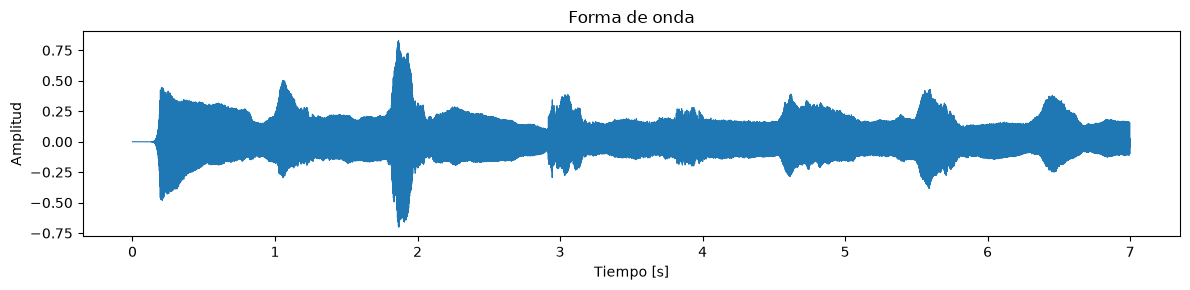

Escucha:


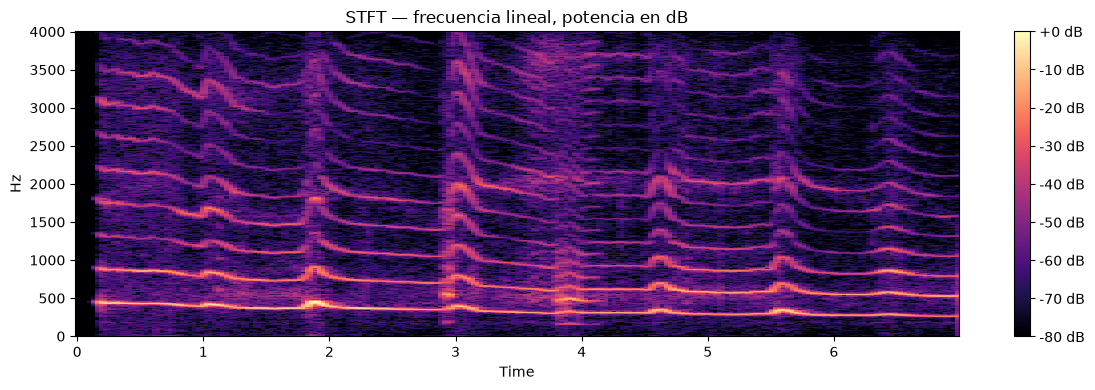

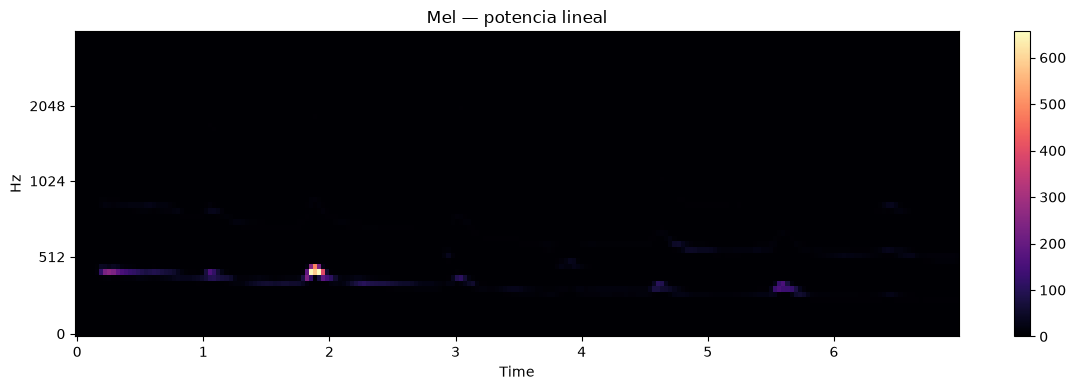

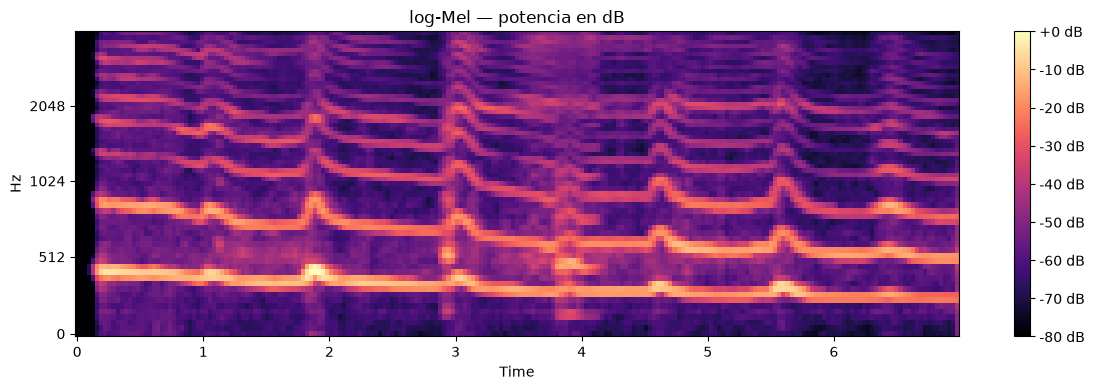

In [16]:
inspect_example("A")

### Observación clave

> **Periodicidad no significa necesariamente frecuencia constante.**

## 7. Ejemplo C — modulación pronunciada de F0

Preguntas guía:

- ¿Se mueve una sola banda o toda la familia armónica?
- ¿Qué segmentos parecen pertenecer a regímenes distintos?
- ¿La modulación es visible además de ser estimable numéricamente?

Ejemplo C — Modulación pronunciada de F0
Archivo: cda99fcf-d010-47b4-8987-f54be313ddbd-1429973787766-1.7-f-26-hu.wav
sr = 8000 Hz
duración = 6.940 s
Nyquist = 4000 Hz
peak = 0.2067
RMS = 0.0367


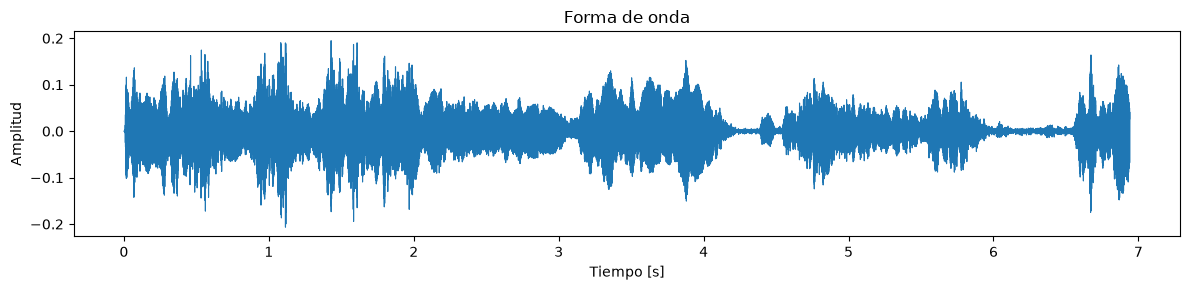

Escucha:


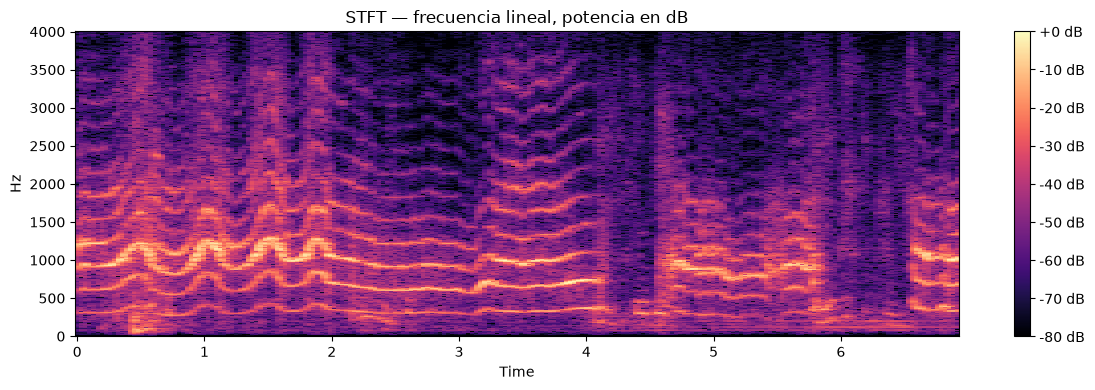

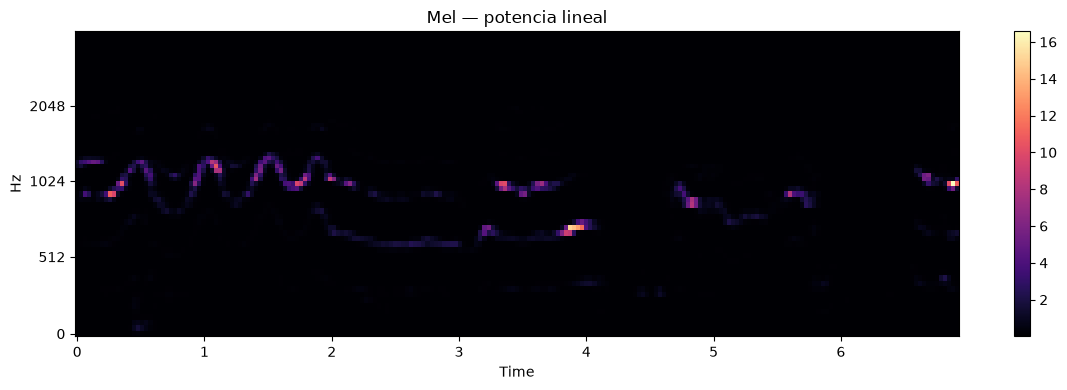

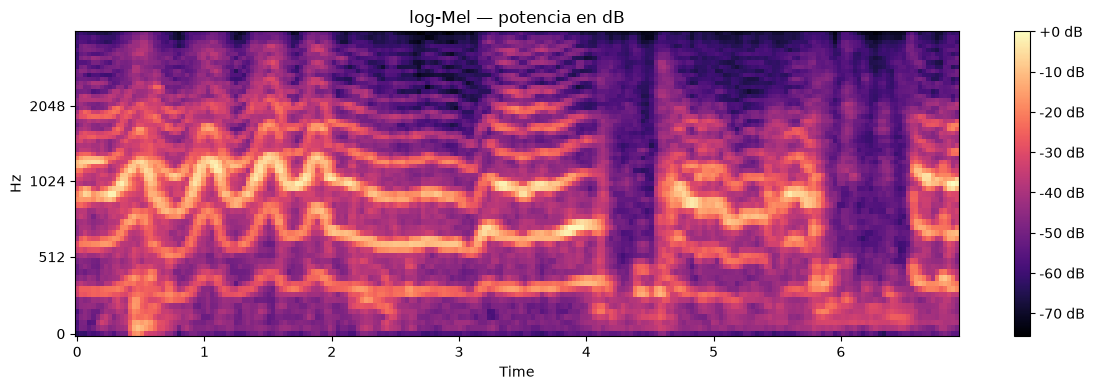

In [17]:
inspect_example("C")

### Extensión opcional — estimar F0 no significa conocer “la verdad”

Usaremos `librosa.pyin`. La trayectoria estimada es una **hipótesis computacional** que debemos contrastar con la escucha y el espectrograma.

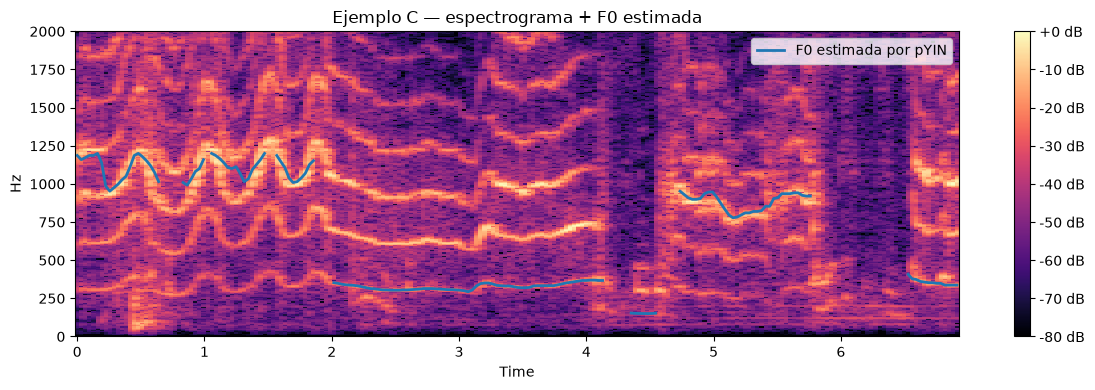

In [18]:
path_c, y_c, sr_c = load_example("C")

f0, voiced_flag, voiced_prob = librosa.pyin(
    y_c,
    fmin=150,
    fmax=min(1200, 0.45 * sr_c),
    sr=sr_c,
    frame_length=N_FFT,
    hop_length=HOP_LENGTH,
)

times = librosa.times_like(f0, sr=sr_c, hop_length=HOP_LENGTH)

D_c = librosa.stft(y_c, n_fft=N_FFT, hop_length=HOP_LENGTH)
S_c_db = librosa.amplitude_to_db(np.abs(D_c), ref=np.max)

plt.figure(figsize=(12, 4))
librosa.display.specshow(
    S_c_db, sr=sr_c, hop_length=HOP_LENGTH,
    x_axis="time", y_axis="linear"
)
plt.plot(times, f0, linewidth=2, label="F0 estimada por pYIN")
plt.ylim(0, 2000)
plt.legend()
plt.colorbar(format="%+2.0f dB")
plt.title("Ejemplo C — espectrograma + F0 estimada")
plt.tight_layout()
plt.show()

### Pregunta para discutir

> ¿En qué regiones confiarías más en la trayectoria de F0?

Una *feature* calculada por Python no se convierte automáticamente en una verdad física.

## 8. Ejemplo D — estructura temporal y segmentación

Preguntas guía:

- ¿Cuántos episodios principales distinguirías?
- ¿Dónde ubicarías sus inicios y finales?
- Después del tercer episodio, ¿hay realmente silencio?
- ¿Qué revela el log-Mel que la waveform hace difícil apreciar?

Ejemplo D — Estructura temporal y segmentación
Archivo: 1309B82C-F146-46F0-A723-45345AFA6EA8-1431172241-1.0-f-48-ti.wav
sr = 8000 Hz
duración = 7.000 s
Nyquist = 4000 Hz
peak = 0.7976
RMS = 0.0751


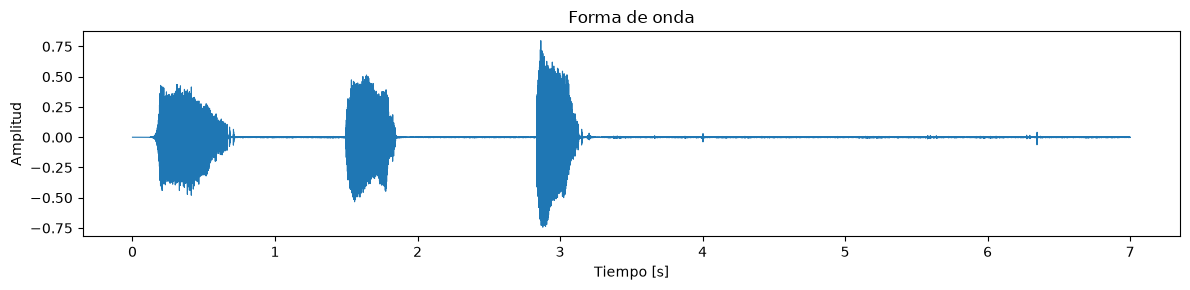

Escucha:


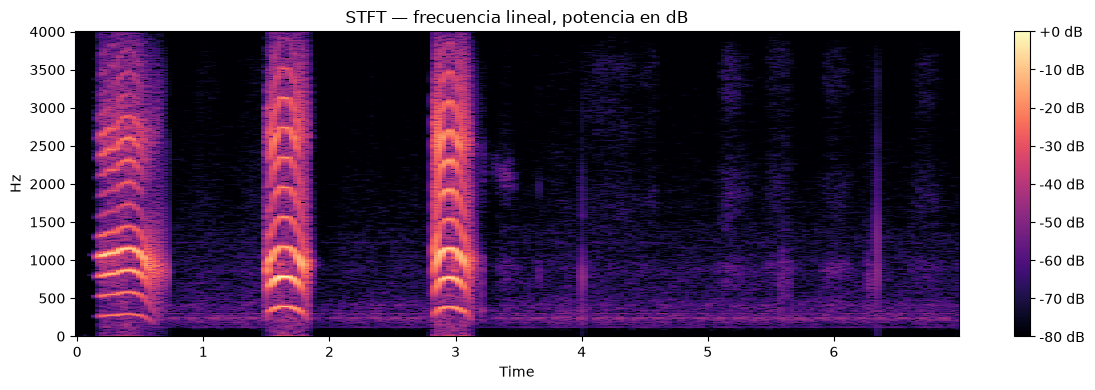

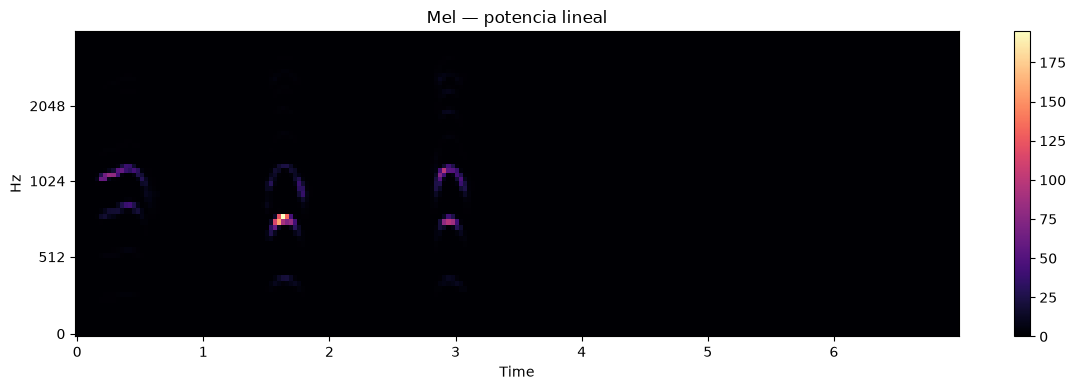

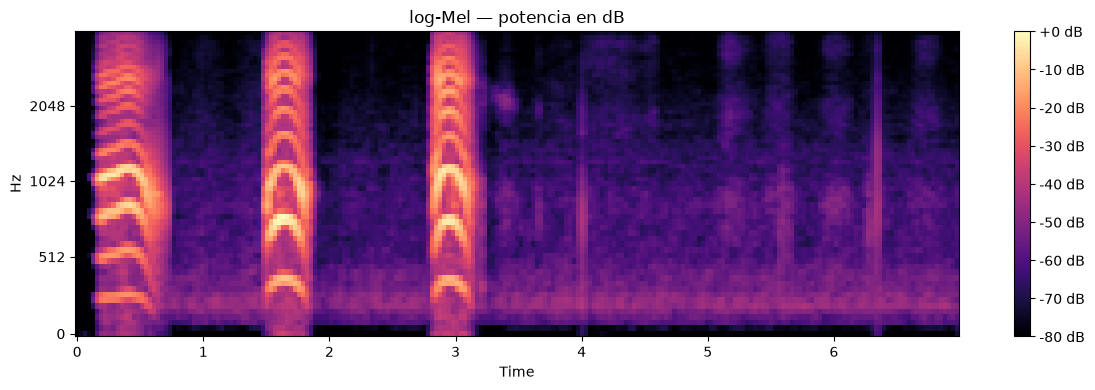

In [19]:
inspect_example("D")

### Observación clave

Una amplitud pequeña no equivale necesariamente a ausencia de señal.

Una grabación también puede pensarse como una secuencia de **eventos**, no como un único bloque.

## 9. Ejemplo F — nivel, textura y cambios de régimen

Preguntas guía:

- ¿Qué tan distintos son los regímenes temporales?
- ¿Cómo cambian las trayectorias armónicas?
- ¿Podemos inferir una “causa” del llanto solo mirando estas figuras?

Ejemplo F — Nivel alto, textura y cambios de régimen
Archivo: af30880e-5f98-4dc0-b37a-be6b21fa0ba3-1431240072536-1.7-m-26-bu.wav
sr = 8000 Hz
duración = 6.540 s
Nyquist = 4000 Hz
peak = 0.9779
RMS = 0.2435


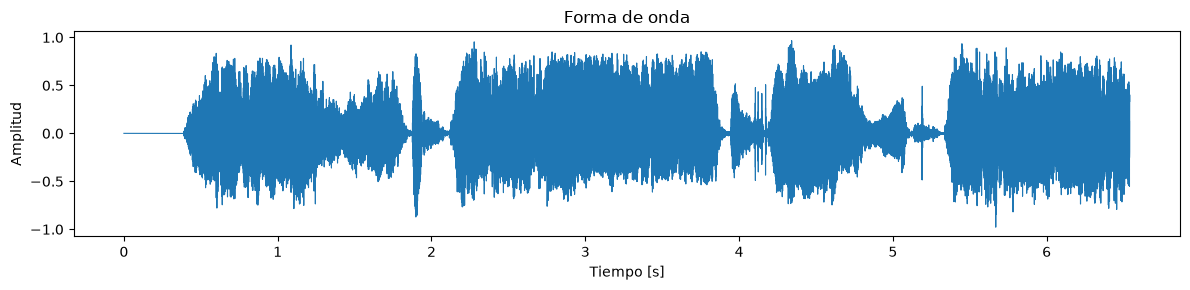

Escucha:


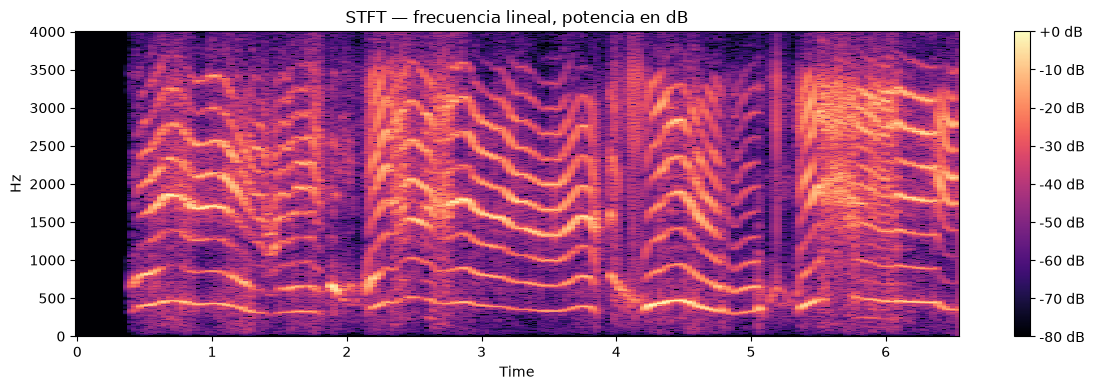

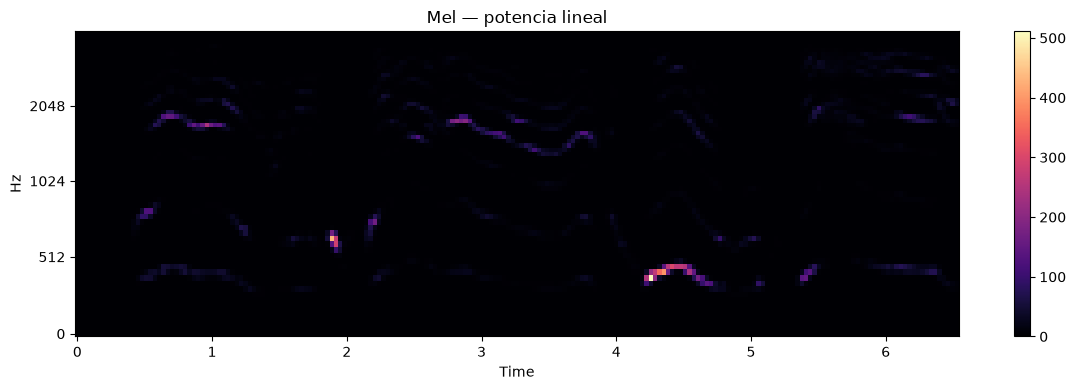

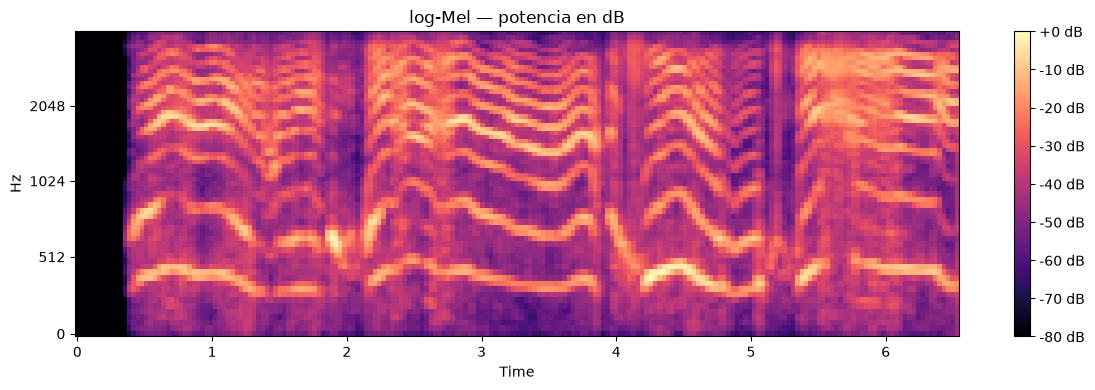

In [20]:
inspect_example("F")

### Precaución de interpretación

El archivo pertenece a una carpeta etiquetada `burping`, pero eso no demuestra que la estructura acústica observada sea una firma específica de esa causa.

```text
etiqueta del dataset ≠ propiedad acústica demostrada ≠ diagnóstico
```

## 10. Comparación final

| Ejemplo | Fenómeno principal | Pregunta que habilita |
|---|---|---|
| A | periodicidad + armónicos + modulación suave | ¿periodicidad exige frecuencia constante? |
| C | modulación pronunciada de F0 | ¿cómo validamos una feature automática? |
| D | episodios + pausas + baja energía | ¿cómo segmentamos una grabación? |
| F | alto nivel + textura + cambios de régimen | ¿qué podemos inferir y qué no desde una representación? |

El objetivo no era encontrar “el mejor audio”, sino ejemplos que permitieran **hacer mejores preguntas**.

## 11. Cierre

Hoy no entrenamos ningún modelo y, sin embargo, ya aprendimos mucho sobre los datos.

Una siguiente etapa podría estudiar RMS, F0, centroide espectral, ancho de banda, zero-crossing rate y MFCC.

> **Primero conocemos los datos. Después elegimos las herramientas.**